# Example of the AiTLAS toolbox for multilabel classification using Copernicus-FM

## Define the FAIREOSchema for dataset import

In [1]:
from marshmallow import fields

from aitlas.base.schemas import BaseDatasetSchema


class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for FAIREO datasets.
    """

    csv_file = fields.String(
        load_default=None,
        metadata={"description": "CSV file on disk", "example": "./data/train.csv"},
    )
    data_dir = fields.String(
        load_default="/",
        metadata={"description": "Dataset path on disk", "example": "./data/CESBIO/"},
    )
    selection = fields.String(
        load_default="rgb",
        metadata={"description": "Read RGB channels or 13 channels", "example": "all/rgb"},
    )

/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dragik/tadej/aitlas/aitlas/models/AnySat/utils/irpe.py:18: UserWarning: 
  warnings.warn(
/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Define the DLRSD Multilabel dataset
DLRSD (Dense Labeling Remote Sensing Dataset) is a dense labeling dataset that can be used for multi-label tasks such as remote sensing image retrieval (RSIR) and 
classification, and other pixel-based tasks like semantic segmentation. It has 21 broad categories with 100 images per class, and 17 segmentation classes. This 
dataloader considers the multi-label classification subset.

In [2]:
import numpy as np
import os
import pandas as pd
import csv

from aitlas.datasets.multilabel_classification import MultiLabelClassificationDataset
from aitlas.utils import image_loader


LABELS = [
    "airplane",
    "baresoil",
    "buildings",
    "cars",
    "chaparral",
    "court",
    "dock",
    "field",
    "grass",
    "mobilehome",
    "pavement",
    "sand",
    "sea",
    "ship",
    "tanks",
    "trees",
    "water",
]


class DLRSDMultilabelDataset(MultiLabelClassificationDataset):
    url = "https://sites.google.com/view/zhouwx/dataset"

    labels = LABELS
    name = "DLRSD multilabel"

    def __init__(self, config):
        # now call the constructor to validate the schema and load the data
        super().__init__(config)
        # this can be overridden if needed
        self.image_loader = image_loader

        # load the data
        self.data_dir = self.config.data_dir
        self.csv_file = self.config.csv_file
        self.data = self.load_dataset(self.data_dir, self.csv_file)

    def __getitem__(self, index):
        """
        Args:
            index (int): Index

        Returns:
            tuple: (image, target) where target is a multi-hot vector.
        """
        # load image
        img = self.image_loader(self.data[index][0])
        if self.transform:
            img = self.transform(img)
        target = self.data[index][1]
        if self.target_transform:
            target = self.target_transform(target)
        return img, target

    def load_dataset(self, data_dir, csv_file):
        # If not provided initialize the labels from the csv file
        if not self.labels:
            with open(csv_file, "rb") as f:
                header = f.readline().decode("utf-8")
                self.labels = header[header.find(",") + 1 :].strip().split(",")

        # read labels
        multi_hot_labels = {}
        with open(csv_file, "rb") as f:
            lines = f.readlines()
            for line in lines[1:]:
                line = line.decode("utf-8").strip()
                if not line:
                    continue
                labels_list = line[line.find(",") + 1 :].split(",")
                cleaned_labels = [label.strip() if label.strip() else "0" for label in labels_list]
                multi_hot_labels[line[: line.find(",")]] = np.asarray(
                    list((map(float, cleaned_labels)))
                )

        images = []
        images_folder = os.path.expanduser(data_dir)
        # this ensures the image always have the same index numbers
        for root, _, fnames in sorted(os.walk(images_folder)):
            for fname in sorted(fnames):
                path = os.path.join(root, fname)
                if fname[: fname.find(".")] in multi_hot_labels:
                    multi_hot_label = multi_hot_labels[fname[: fname.find(".")]]
                    item = (path, multi_hot_label)
                    images.append(item)

        return images

    def show_samples(self):
        df = pd.read_csv(self.csv_file, sep=",")
        return df.head(20)

    def data_distribution_table(self):
        df = pd.read_csv(self.csv_file, sep=",")
        label_count = pd.DataFrame(df.sum(axis=0)).reset_index()
        label_count.columns = ["Label", "Count"]
        label_count.drop(label_count.index[0], inplace=True)
        return label_count

/home/dragik/tadej/aitlas/.venv/lib/python3.12/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


## Visualize images and masks

Total number of patches: 1241


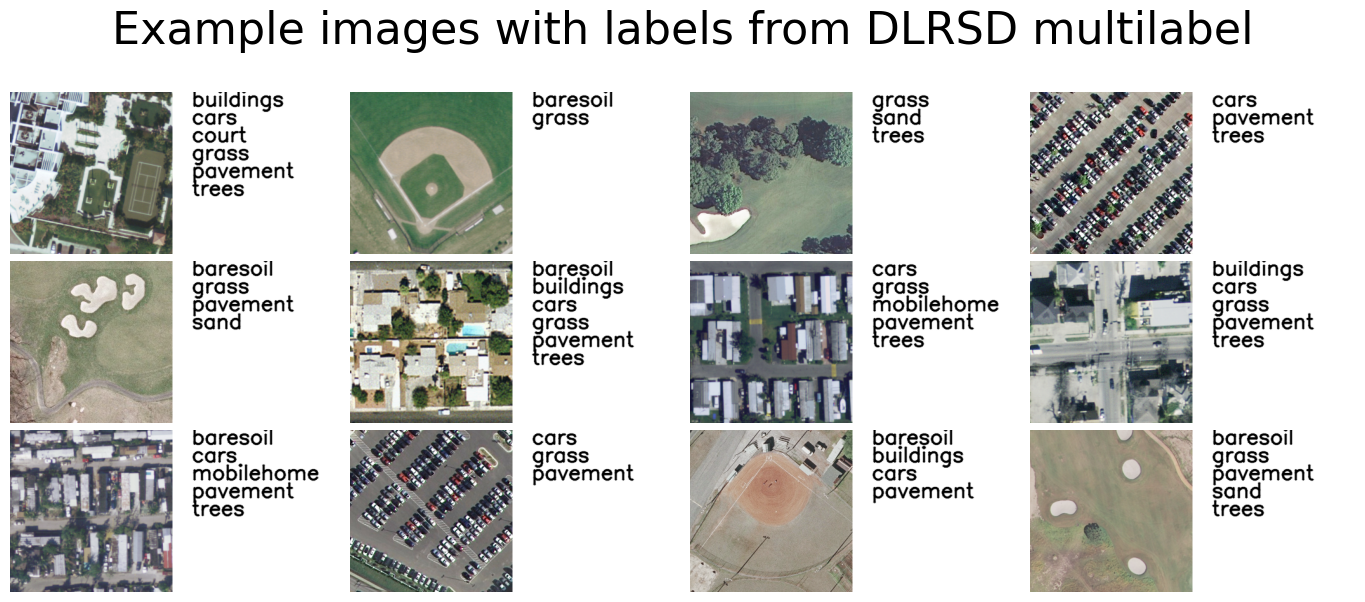

In [3]:
dataset_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/Images/",
    "csv_file": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/dlrsd_multilabel_train.csv",
}
dataset = DLRSDMultilabelDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")
fig = dataset.show_batch(12)

## Define train and test datasets

In [4]:
# Train dataset
train_dataset_config = {
    "batch_size": 8,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/Images/",
    "csv_file": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/dlrsd_multilabel_train.csv",
    "transforms": ["aitlas.transforms.ResizeRandomCropFlipHVToTensor"]
}
train_dataset = DLRSDMultilabelDataset(train_dataset_config)
print(f"Number of training samples: {len(train_dataset)}")

# Validation dataset
val_dataset_config = {
    "batch_size": 8,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/Images/",
    "csv_file": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/dlrsd_multilabel_val.csv",
    "transforms": ["aitlas.transforms.ResizeRandomCropFlipHVToTensor"] 
}
val_dataset = DLRSDMultilabelDataset(val_dataset_config)
print(f"Number of validation samples: {len(val_dataset)}")

# Test dataset
test_dataset_config = {
    "batch_size": 4,
    "shuffle": False,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/Images/",
    "csv_file": "/home/dragik/data/FAIR_EO/dlrsd_multilabel/DLRSD/dlrsd_multilabel_test.csv",
    "transforms": ["aitlas.transforms.ResizeRandomCropFlipHVToTensor"]
}

test_dataset = DLRSDMultilabelDataset(test_dataset_config)
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 1241
Number of validation samples: 431
Number of test samples: 428


## Prepare the model

In [5]:
import torch
from aitlas.base import CompositeModel


# Define the config file
config_data = {
    # Task definition
    "task_type": "multilabel classification",
    "num_classes": 17,
    # Training parameters
    "learning_rate": 0.0001,
    "metrics": ["accuracy", "precision", "recall", "f1_score", "map", "roc_auc_score", "hamming_loss"],
    # Data-model adapter configuration
    "adapter_name": "CopernicusFMAdapter",
    "bands": ["B02", "B03", "B04"],
    # Backbone configuration
    "local_model_path": "tests/checkpoints/CopernicusFM_ViT_base_varlang_e100.pth",
    "backbone_name": "copernicusfm_base",
    "pretrained": True,
    # Head configuration
    "head_name": "ScalarHead"
}

print(f"Instantiating CompositeModel with backbone: {config_data['backbone_name']}")

# Instantiate the CompositeModel
model = CompositeModel(config_data)
model.prepare()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Print the architecture
print("\nComposite model architecture created:")
print(f"  Adapter:  {type(model.input_adapter).__name__}")
print(f"  Backbone: {type(model.model.backbone).__name__}")
print(f"  Head:     {type(model.model.head).__name__}")
print(f"\nModel successfully loaded on device: {device}")

Instantiating CompositeModel with backbone: copernicusfm_base
Loading weights from the provided local path: tests/checkpoints/CopernicusFM_ViT_base_varlang_e100.pth
Successfully loaded checkpoint: CopernicusFM_ViT_base_varlang_e100.pth

Composite model architecture created:
  Adapter:  CopernicusFMAdapter
  Backbone: CopernicusFM
  Head:     ScalarHead

Model successfully loaded on device: cuda:0


## Train and evaluate the model

In [6]:
epochs = 10
model_directory = "/home/dragik/data/FAIR_EO/experiments/dlrsd_multilabel/"

model.train_and_evaluate_model(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id='1'
);

2026-05-06 11:14:30,916 INFO Starting training.
training: 100%|██████████| 156/156 [00:12<00:00, 12.67it/s]
2026-05-06 11:14:43,244 INFO epoch: 1, time: 13, loss:  0.40855
testing on train set: 100%|██████████| 156/156 [00:04<00:00, 34.75it/s]
2026-05-06 11:14:51,859 INFO Accuracy:0.8408778499312698, Accuracy per Class:[0.95165189 0.67042707 0.65511684 0.75664786 0.94359388 0.94923449
 0.95084609 0.95004029 0.55519742 0.95084609 0.73005641 0.85898469
 0.95084609 0.94923449 0.95165189 0.62207897 0.89846898], Precision Micro:0.6902920962199313, Precision Macro:0.23436818437905374, Precision Weighted:0.5142915586874943, Precision per Class:[0.         0.82089552 0.         0.74481328 0.         0.
 0.         0.         0.765625   0.         0.72176591 0.
 0.         0.         0.         0.59782609 0.33333333], Recall Micro:0.3787414565166156, Recall Macro:0.14793675470070286, Recall Weighted:0.3787414565166156, Recall per Class:[0.         0.12168142 0.         0.66728625 0.         0.


## Make predictions

In [ ]:
from aitlas.transforms import ResizeCenterCropToTensor

# Load the model
model_path = "/home/dragik/data/FAIR_EO/experiments/dlrsd_multilabel/checkpoint.pth.tar"
device = torch.device("cuda:0")
model.device = device
model.load_model(model_path)

# Define the labels and transformation
labels = DLRSDMultilabelDataset.labels
transform = ResizeCenterCropToTensor()

# Predict on a test image
image = test_dataset[1][0]
fig = model.predict_image(image, labels, transform)